In [1]:
import gpytorch
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from h2_dispersion_gp import VNNGP, SparseH2DispersionGP
import pandas as pd
from h2_dispersion_gp import load_model, evaluate_gp_model

In [2]:
# Load data
df = pd.read_csv('/home/niclasflehmig/VisualCodeProjects/H2-dispersion-model/data/unified_raw_two_modes.csv')

# Sensor positions (should match your data)
SENSOR_POSITIONS = {
    1: (0.77, 0.24, 0.8), 2: (0.46, 0.0, 0.8), 3: (0.48, 0.25, 0.52),
    4: (0.13, 0.26, 0.8), 5: (0.48, 1.33, 0.52), 6: (0.46, 1.11, 0.8),
    7: (0.9, 2.22, 0.8), 8: (0.47, 2.46, 0.52), 9: (0.46, 2.22, 0.8),
    10: (0.74, 2.45, 0.8), 11: (0.15, 2.44, 0.8), 12: (0.00, 2.22, 0.8),
    13: (0.47, 3.54, 0.52), 14: (0.46, 3.31, 0.8), 15: (0.78, 4.65, 0.8),
    17: (0.46, 4.39, 0.8), 18: (0.47, 4.63, 0.52), 19: (0.14, 4.68, 0.52),
    20: (0.75, 0.24, 0.0), 21: (0.45, 0.0, 0.0), 22: (0.16, 0.24, 0.0),
    23: (0.47, 0.24, 0.28), 24: (0.46, 1.33, 0.27), 25: (0.47, 1.1, 0.0),
    26: (0.46, 2.46, 0.27), 27: (0.47, 2.23, 0.0), 28: (0.47, 3.56, 0.27),
    29: (0.47, 4.63, 0.27), 30: (0.46, 4.44, 0.0),
}

df_test = df[df['split'] == 'test'].copy()

# SVGP 4000 Gaussian

In [13]:
checkpoint = torch.load('models/approximate_indvAdditive_svgp_rbf_4000_gaussian_two_modes_300_lr8e-3.pth_best', map_location='cpu')
inducing_points = checkpoint['model_state_dict']['variational_strategy.inducing_points']
likelihood = gpytorch.likelihoods.GaussianLikelihood().double().to('cpu')
model = SparseH2DispersionGP(inducing_points=inducing_points).double().to('cpu')

In [8]:
model_state_dict = checkpoint['model_state_dict']
likelihood_state_dict = checkpoint['likelihood_state_dict']

model.load_state_dict(model_state_dict)
likelihood.load_state_dict(likelihood_state_dict)

<All keys matched successfully>

In [12]:
import torch.nn.functional as F

state = checkpoint['model_state_dict']

for key in sorted(state.keys()):
    if 'covar_module' in key:
        val = state[key]
        if 'raw_outputscale' in key:
            print(f"{key:<50} → {F.softplus(val).item():.4f}")
        elif 'raw_lengthscale' in key:
            print(f"{key:<50} → {F.softplus(val).tolist()}")

covar_module.kernels.0.base_kernel.raw_lengthscale → [[2.4294197874839143, 4.645011468441091]]
covar_module.kernels.0.base_kernel.raw_lengthscale_constraint.lower_bound → 0.6931471805599453
covar_module.kernels.0.base_kernel.raw_lengthscale_constraint.upper_bound → inf
covar_module.kernels.0.raw_outputscale             → 0.0409
covar_module.kernels.0.raw_outputscale_constraint.lower_bound → 0.6931
covar_module.kernels.0.raw_outputscale_constraint.upper_bound → inf
covar_module.kernels.1.base_kernel.raw_lengthscale → [[2.4043269973447257, 2.658696303371859]]
covar_module.kernels.1.base_kernel.raw_lengthscale_constraint.lower_bound → 0.6931471805599453
covar_module.kernels.1.base_kernel.raw_lengthscale_constraint.upper_bound → inf
covar_module.kernels.1.raw_outputscale             → 0.0919
covar_module.kernels.1.raw_outputscale_constraint.lower_bound → 0.6931
covar_module.kernels.1.raw_outputscale_constraint.upper_bound → inf
covar_module.kernels.10.base_kernel.raw_lengthscale → [[3.4056

In [8]:
# 1. Load model + checkpoint
device = 'cpu'
model_4000, likelihood_4000, checkpoint_4000 = load_model('models/approximate_indvAdditive_svgp_rbf_4000_gaussian_two_modes_300_lr8e-3.pth_best', device=device)

# 2. Load test data (must be the same unified CSV used for training)
df = pd.read_csv('data/unified_raw_two_modes.csv')
df_test = df[df['split'] == 'test']

# 3. Evaluate
metrics = evaluate_gp_model(
    model=model_4000,
    likelihood=likelihood_4000,
    df_test=df_test,
    device=device,
    x_scaler=checkpoint_4000.get('x_scaler'),
    y_scaler=checkpoint_4000.get('y_scaler')
)


TEST EVALUATION
Test data: 28,188 points

Test Metrics:
  NLL:      13.6988
  MAE:      0.021043
  RMSE:     0.026312


In [10]:
x_scaler = checkpoint_4000.get('x_scaler')   # StandardScaler or None
y_scaler = checkpoint_4000.get('y_scaler')   # StandardScaler or None

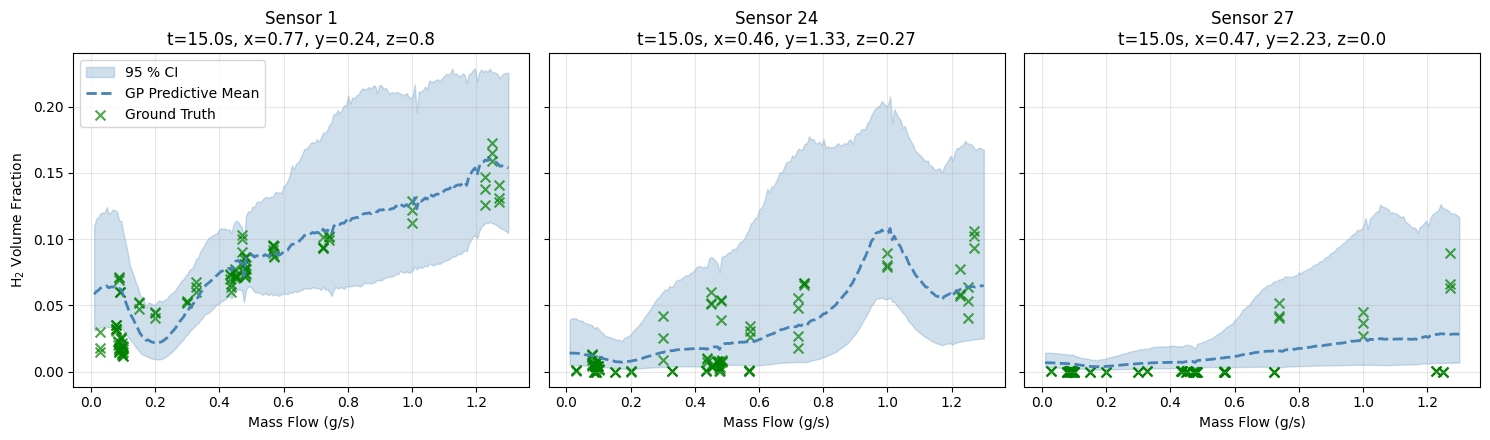

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import gpytorch

# --- Three fixed positions ---------------------------------------------------
positions = [
    {'time': 15.0, 'x': 0.77, 'y': 0.24, 'z': 0.80, 'label': 'Sensor 1'},
    {'time': 15.0, 'x': 0.46, 'y': 1.33, 'z': 0.27, 'label': 'Sensor 24'},
    {'time': 15.0, 'x': 0.47, 'y': 2.23, 'z': 0.00, 'label': 'Sensor 27'},
]

mass_flow_grid = np.linspace(0.01, 1.30, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
axes = axes.flatten()

for ax, pos in zip(axes, positions):
    # Build input grid
    grid = np.column_stack([
        np.full_like(mass_flow_grid, pos['time']),
        mass_flow_grid,
        np.full_like(mass_flow_grid, pos['x']),
        np.full_like(mass_flow_grid, pos['y']),
        np.full_like(mass_flow_grid, pos['z']),
    ])

    if x_scaler is not None:
        grid_scaled = x_scaler.transform(grid)
    else:
        grid_scaled = grid

    X_grid = torch.tensor(grid_scaled, dtype=torch.float64, device=device)

    # Predict
    model_4000.eval()
    likelihood_4000.eval()
    with torch.no_grad():
        pred = likelihood_4000(model_4000(X_grid))
        pred_mean = pred.mean.cpu().numpy()
        lower, upper = pred.confidence_region()
        lower = lower.cpu().numpy()
        upper = upper.cpu().numpy()

    is_beta = isinstance(likelihood_4000, gpytorch.likelihoods.BetaLikelihood)
    if not is_beta:
        if y_scaler is not None:
            pred_mean = np.exp(y_scaler.inverse_transform(pred_mean.reshape(-1, 1))).ravel()
            lower = np.exp(y_scaler.inverse_transform(lower.reshape(-1, 1))).ravel()
            upper = np.exp(y_scaler.inverse_transform(upper.reshape(-1, 1))).ravel()
        else:
            pred_mean = np.exp(pred_mean)
            lower = np.exp(lower)
            upper = np.exp(upper)

    # Ground truth
    tol = 0.01
    df_gt = df[
        (np.abs(df['time'] - pos['time']) < 1.0) &
        (np.abs(df['x'] - pos['x']) < tol) &
        (np.abs(df['y'] - pos['y']) < tol) &
        (np.abs(df['z'] - pos['z']) < tol)
    ].copy()

    # Plot
    ax.fill_between(mass_flow_grid, lower, upper, color='steelblue', alpha=0.25,
                    label='95 % CI' if ax == axes[0] else '')
    ax.plot(mass_flow_grid, pred_mean, color='steelblue', linewidth=2,
            linestyle='--', label='GP Predictive Mean' if ax == axes[0] else '')
    ax.scatter(df_gt['mass_flow'], df_gt['h2_volume_fraction'],
               c='green', marker='x', s=50, alpha=0.7,
               label='Ground Truth' if ax == axes[0] else '')

    ax.set_xlabel('Mass Flow (g/s)')
    ax.set_title(f"{pos['label']}\nt={pos['time']}s, x={pos['x']}, y={pos['y']}, z={pos['z']}")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('H$_2$ Volume Fraction')
axes[0].legend(loc='best')
plt.tight_layout()
plt.show()

## SVGP 5000

In [25]:
checkpoint = torch.load('models/approximate_indvAdditive_svgp_rbf_5000_gaussian_two_modes_300_lr8e-3.pth_best', map_location='cpu')
inducing_points = checkpoint['model_state_dict']['variational_strategy.inducing_points']
likelihood = gpytorch.likelihoods.GaussianLikelihood().double().to('cpu')
model = SparseH2DispersionGP(inducing_points=inducing_points).double().to('cpu')

In [26]:
model_state_dict = checkpoint['model_state_dict']
likelihood_state_dict = checkpoint['likelihood_state_dict']

model.load_state_dict(model_state_dict)
likelihood.load_state_dict(likelihood_state_dict)

<All keys matched successfully>

In [27]:
import torch.nn.functional as F

state = checkpoint['model_state_dict']

for key in sorted(state.keys()):
    if 'covar_module' in key:
        val = state[key]
        if 'raw_outputscale' in key:
            print(f"{key:<50} → {F.softplus(val).item():.4f}")
        elif 'raw_lengthscale' in key:
            print(f"{key:<50} → {F.softplus(val).tolist()}")

covar_module.kernels.0.base_kernel.raw_lengthscale → [[2.8837794170919704, 8.49675656056473]]
covar_module.kernels.0.base_kernel.raw_lengthscale_constraint.lower_bound → 0.6931471805599453
covar_module.kernels.0.base_kernel.raw_lengthscale_constraint.upper_bound → inf
covar_module.kernels.0.raw_outputscale             → 0.0509
covar_module.kernels.0.raw_outputscale_constraint.lower_bound → 0.6931
covar_module.kernels.0.raw_outputscale_constraint.upper_bound → inf
covar_module.kernels.1.base_kernel.raw_lengthscale → [[2.282021319852246, 3.992882058473794]]
covar_module.kernels.1.base_kernel.raw_lengthscale_constraint.lower_bound → 0.6931471805599453
covar_module.kernels.1.base_kernel.raw_lengthscale_constraint.upper_bound → inf
covar_module.kernels.1.raw_outputscale             → 0.1494
covar_module.kernels.1.raw_outputscale_constraint.lower_bound → 0.6931
covar_module.kernels.1.raw_outputscale_constraint.upper_bound → inf
covar_module.kernels.10.base_kernel.raw_lengthscale → [[5.380526

In [12]:
# 1. Load model + checkpoint
device = 'cpu'
model_5000, likelihood_5000, checkpoint_5000 = load_model('models/approximate_indvAdditive_svgp_rbf_5000_gaussian_two_modes_300_lr8e-3.pth_best', device=device)

# 2. Load test data (must be the same unified CSV used for training)
df = pd.read_csv('data/unified_raw_two_modes.csv')
df_test = df[df['split'] == 'test']

# 3. Evaluate
metrics = evaluate_gp_model(
    model=model_5000,
    likelihood=likelihood_5000,
    df_test=df_test,
    device=device,
    x_scaler=checkpoint_5000.get('x_scaler'),
    y_scaler=checkpoint_5000.get('y_scaler')
)


TEST EVALUATION
Test data: 28,188 points

Test Metrics:
  NLL:      13.8401
  MAE:      0.021121
  RMSE:     0.026242


In [13]:
x_scaler = checkpoint_5000.get('x_scaler')   # StandardScaler or None
y_scaler = checkpoint_5000.get('y_scaler')   # StandardScaler or None

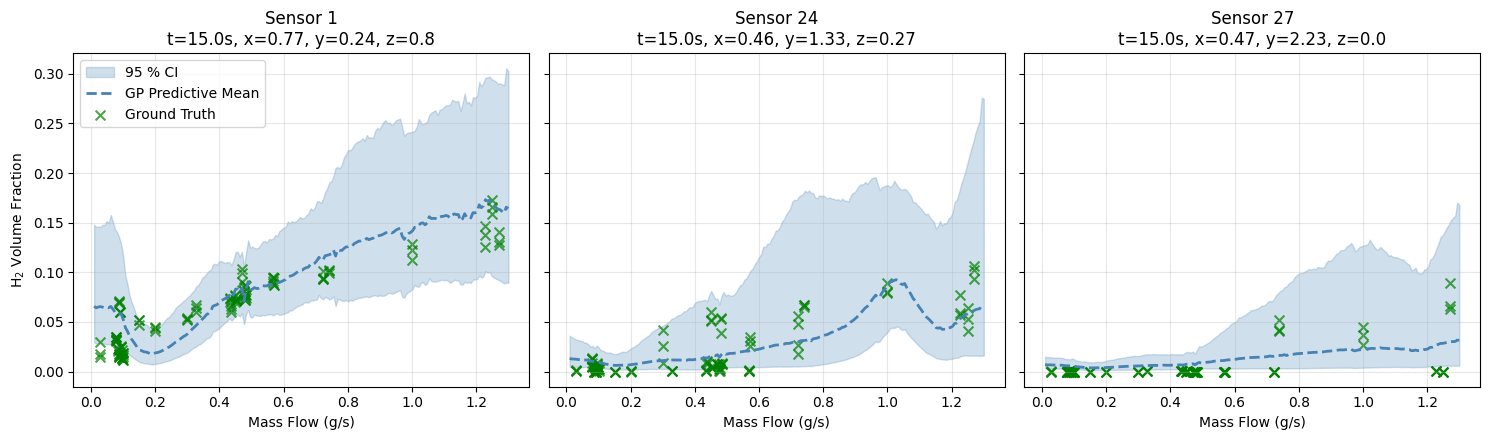

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import gpytorch

# --- Three fixed positions ---------------------------------------------------
positions = [
    {'time': 15.0, 'x': 0.77, 'y': 0.24, 'z': 0.80, 'label': 'Sensor 1'},
    {'time': 15.0, 'x': 0.46, 'y': 1.33, 'z': 0.27, 'label': 'Sensor 24'},
    {'time': 15.0, 'x': 0.47, 'y': 2.23, 'z': 0.00, 'label': 'Sensor 27'},
]

mass_flow_grid = np.linspace(0.01, 1.30, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
axes = axes.flatten()

for ax, pos in zip(axes, positions):
    # Build input grid
    grid = np.column_stack([
        np.full_like(mass_flow_grid, pos['time']),
        mass_flow_grid,
        np.full_like(mass_flow_grid, pos['x']),
        np.full_like(mass_flow_grid, pos['y']),
        np.full_like(mass_flow_grid, pos['z']),
    ])

    if x_scaler is not None:
        grid_scaled = x_scaler.transform(grid)
    else:
        grid_scaled = grid

    X_grid = torch.tensor(grid_scaled, dtype=torch.float64, device=device)

    # Predict
    model_5000.eval()
    likelihood_5000.eval()
    with torch.no_grad():
        pred = likelihood_5000(model_5000(X_grid))
        pred_mean = pred.mean.cpu().numpy()
        lower, upper = pred.confidence_region()
        lower = lower.cpu().numpy()
        upper = upper.cpu().numpy()

    is_beta = isinstance(likelihood_5000, gpytorch.likelihoods.BetaLikelihood)
    if not is_beta:
        if y_scaler is not None:
            pred_mean = np.exp(y_scaler.inverse_transform(pred_mean.reshape(-1, 1))).ravel()
            lower = np.exp(y_scaler.inverse_transform(lower.reshape(-1, 1))).ravel()
            upper = np.exp(y_scaler.inverse_transform(upper.reshape(-1, 1))).ravel()
        else:
            pred_mean = np.exp(pred_mean)
            lower = np.exp(lower)
            upper = np.exp(upper)

    # Ground truth
    tol = 0.01
    df_gt = df[
        (np.abs(df['time'] - pos['time']) < 1.0) &
        (np.abs(df['x'] - pos['x']) < tol) &
        (np.abs(df['y'] - pos['y']) < tol) &
        (np.abs(df['z'] - pos['z']) < tol)
    ].copy()

    # Plot
    ax.fill_between(mass_flow_grid, lower, upper, color='steelblue', alpha=0.25,
                    label='95 % CI' if ax == axes[0] else '')
    ax.plot(mass_flow_grid, pred_mean, color='steelblue', linewidth=2,
            linestyle='--', label='GP Predictive Mean' if ax == axes[0] else '')
    ax.scatter(df_gt['mass_flow'], df_gt['h2_volume_fraction'],
               c='green', marker='x', s=50, alpha=0.7,
               label='Ground Truth' if ax == axes[0] else '')

    ax.set_xlabel('Mass Flow (g/s)')
    ax.set_title(f"{pos['label']}\nt={pos['time']}s, x={pos['x']}, y={pos['y']}, z={pos['z']}")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('H$_2$ Volume Fraction')
axes[0].legend(loc='best')
plt.tight_layout()
plt.show()

# SVGP 6000

In [36]:
checkpoint = torch.load('models/approximate_indvAdditive_svgp_rbf_6000_gaussian_two_modes_300_lr8e-3.pth_best', map_location='cpu')
inducing_points = checkpoint['model_state_dict']['variational_strategy.inducing_points']
likelihood = gpytorch.likelihoods.GaussianLikelihood().double().to('cpu')
model = SparseH2DispersionGP(inducing_points=inducing_points).double().to('cpu')

In [37]:
model_state_dict = checkpoint['model_state_dict']
likelihood_state_dict = checkpoint['likelihood_state_dict']

model.load_state_dict(model_state_dict)
likelihood.load_state_dict(likelihood_state_dict)

<All keys matched successfully>

In [38]:
import torch.nn.functional as F

state = checkpoint['model_state_dict']

for key in sorted(state.keys()):
    if 'covar_module' in key:
        val = state[key]
        if 'raw_outputscale' in key:
            print(f"{key:<50} → {F.softplus(val).item():.4f}")
        elif 'raw_lengthscale' in key:
            print(f"{key:<50} → {F.softplus(val).tolist()}")

covar_module.kernels.0.base_kernel.raw_lengthscale → [[2.6994498633602566, 5.0507415182343]]
covar_module.kernels.0.base_kernel.raw_lengthscale_constraint.lower_bound → 0.6931471805599453
covar_module.kernels.0.base_kernel.raw_lengthscale_constraint.upper_bound → inf
covar_module.kernels.0.raw_outputscale             → 0.0505
covar_module.kernels.0.raw_outputscale_constraint.lower_bound → 0.6931
covar_module.kernels.0.raw_outputscale_constraint.upper_bound → inf
covar_module.kernels.1.base_kernel.raw_lengthscale → [[2.2610001549730963, 3.2886767202122904]]
covar_module.kernels.1.base_kernel.raw_lengthscale_constraint.lower_bound → 0.6931471805599453
covar_module.kernels.1.base_kernel.raw_lengthscale_constraint.upper_bound → inf
covar_module.kernels.1.raw_outputscale             → 0.1157
covar_module.kernels.1.raw_outputscale_constraint.lower_bound → 0.6931
covar_module.kernels.1.raw_outputscale_constraint.upper_bound → inf
covar_module.kernels.10.base_kernel.raw_lengthscale → [[3.26665

In [2]:
# 1. Load model + checkpoint
device = 'cpu'
model_6000, likelihood_6000, checkpoint_6000 = load_model('models/approximate_indvAdditive_svgp_rbf_6000_gaussian_two_modes_300_lr8e-3.pth_best', device=device)

# 2. Load test data (must be the same unified CSV used for training)
df = pd.read_csv('data/unified_raw_two_modes.csv')
df_test = df[df['split'] == 'test']

# 3. Evaluate
metrics = evaluate_gp_model(
    model=model_6000,
    likelihood=likelihood_6000,
    df_test=df_test,
    device=device,
    x_scaler=checkpoint_6000.get('x_scaler'),
    y_scaler=checkpoint_6000.get('y_scaler')
)


TEST EVALUATION
Test data: 28,188 points

Test Metrics:
  NLL:      12.6712
  MAE:      0.020677
  RMSE:     0.025485


In [3]:
x_scaler = checkpoint_6000.get('x_scaler')   # StandardScaler or None
y_scaler = checkpoint_6000.get('y_scaler')   # StandardScaler or None

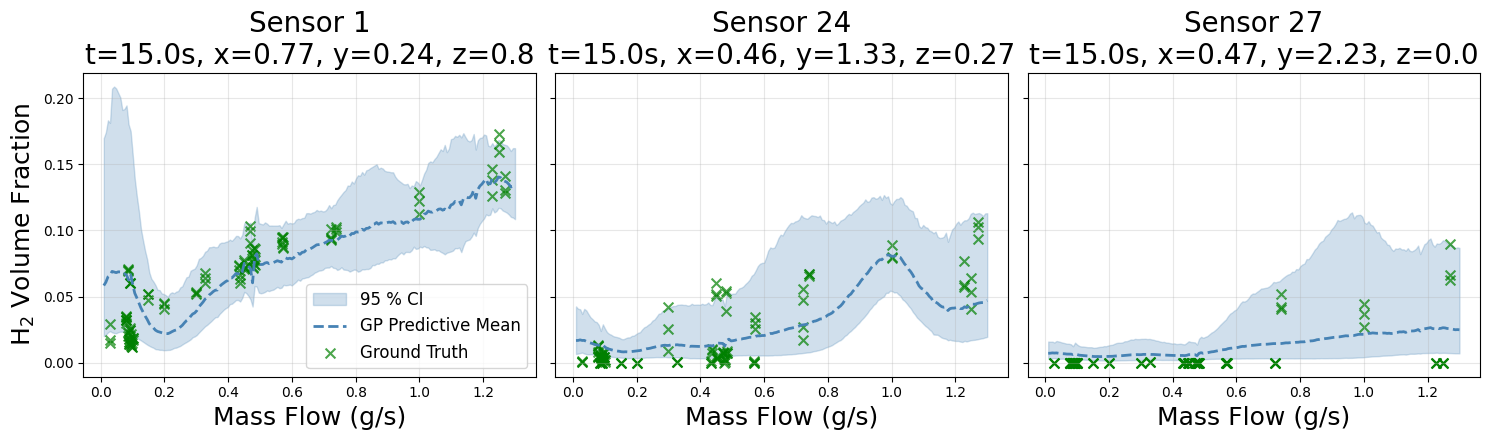

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import gpytorch

# --- Three fixed positions ---------------------------------------------------
positions = [
    {'time': 15.0, 'x': 0.77, 'y': 0.24, 'z': 0.80, 'label': 'Sensor 1'},
    {'time': 15.0, 'x': 0.46, 'y': 1.33, 'z': 0.27, 'label': 'Sensor 24'},
    {'time': 15.0, 'x': 0.47, 'y': 2.23, 'z': 0.00, 'label': 'Sensor 27'},
]

mass_flow_grid = np.linspace(0.01, 1.30, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
axes = axes.flatten()

for ax, pos in zip(axes, positions):
    # Build input grid
    grid = np.column_stack([
        np.full_like(mass_flow_grid, pos['time']),
        mass_flow_grid,
        np.full_like(mass_flow_grid, pos['x']),
        np.full_like(mass_flow_grid, pos['y']),
        np.full_like(mass_flow_grid, pos['z']),
    ])

    if x_scaler is not None:
        grid_scaled = x_scaler.transform(grid)
    else:
        grid_scaled = grid

    X_grid = torch.tensor(grid_scaled, dtype=torch.float64, device=device)

    # Predict
    model_6000.eval()
    likelihood_6000.eval()
    with torch.no_grad():
        pred = likelihood_6000(model_6000(X_grid))
        pred_mean = pred.mean.cpu().numpy()
        lower, upper = pred.confidence_region()
        lower = lower.cpu().numpy()
        upper = upper.cpu().numpy()

    is_beta = isinstance(likelihood_6000, gpytorch.likelihoods.BetaLikelihood)
    if not is_beta:
        if y_scaler is not None:
            pred_mean = np.exp(y_scaler.inverse_transform(pred_mean.reshape(-1, 1))).ravel()
            lower = np.exp(y_scaler.inverse_transform(lower.reshape(-1, 1))).ravel()
            upper = np.exp(y_scaler.inverse_transform(upper.reshape(-1, 1))).ravel()
        else:
            pred_mean = np.exp(pred_mean)
            lower = np.exp(lower)
            upper = np.exp(upper)

    # Ground truth
    tol = 0.01
    df_gt = df[
        (np.abs(df['time'] - pos['time']) < 1.0) &
        (np.abs(df['x'] - pos['x']) < tol) &
        (np.abs(df['y'] - pos['y']) < tol) &
        (np.abs(df['z'] - pos['z']) < tol)
    ].copy()

    # Plot
    ax.fill_between(mass_flow_grid, lower, upper, color='steelblue', alpha=0.25,
                    label='95 % CI' if ax == axes[0] else '')
    ax.plot(mass_flow_grid, pred_mean, color='steelblue', linewidth=2,
            linestyle='--', label='GP Predictive Mean' if ax == axes[0] else '')
    ax.scatter(df_gt['mass_flow'], df_gt['h2_volume_fraction'],
               c='green', marker='x', s=50, alpha=0.7,
               label='Ground Truth' if ax == axes[0] else '')

    ax.set_xlabel('Mass Flow (g/s)', fontsize=18)
    ax.set_title(f"{pos['label']}\nt={pos['time']}s, x={pos['x']}, y={pos['y']}, z={pos['z']}", fontsize=20)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('H$_2$ Volume Fraction', fontsize=18)
axes[0].legend(loc='best', fontsize=12)
plt.tight_layout()
plt.show()

# VNNGP K16

In [3]:
checkpoint = torch.load('models/approximate_indvAdditive_vnngp_rbf_k16_gaussian_two_modes_300_lr9e-3.pth_best', map_location='cpu')
inducing_points = checkpoint['model_state_dict']['variational_strategy.inducing_points']
likelihood = gpytorch.likelihoods.GaussianLikelihood().double().to('cpu')
model = VNNGP(inducing_points=inducing_points, likelihood=likelihood, k=16, training_batch_size=1024).double().to('cpu')

In [13]:
model_state_dict = checkpoint['model_state_dict']
likelihood_state_dict = checkpoint['likelihood_state_dict']

model.load_state_dict(model_state_dict, strict=False)
likelihood.load_state_dict(likelihood_state_dict)

<All keys matched successfully>

In [14]:
import torch.nn.functional as F

state = checkpoint['model_state_dict']

for key in sorted(state.keys()):
    if 'covar_module' in key:
        val = state[key]
        if 'raw_outputscale' in key:
            print(f"{key:<50} → {F.softplus(val).item():.4f}")
        elif 'raw_lengthscale' in key:
            print(f"{key:<50} → {F.softplus(val).tolist()}")

covar_module.base_kernels.0.raw_lengthscale        → [[3.5942282915293226e-05]]
covar_module.base_kernels.0.raw_lengthscale_constraint.lower_bound → 0.6931471805599453
covar_module.base_kernels.0.raw_lengthscale_constraint.upper_bound → inf
covar_module.base_kernels.1.raw_lengthscale        → [[1.7448906106498717e-06]]
covar_module.base_kernels.1.raw_lengthscale_constraint.lower_bound → 0.6981596803955449
covar_module.base_kernels.1.raw_lengthscale_constraint.upper_bound → 10.000045398899218
covar_module.base_kernels.2.raw_lengthscale        → [[4.101965797503375]]
covar_module.base_kernels.2.raw_lengthscale_constraint.lower_bound → 0.6931471805599453
covar_module.base_kernels.2.raw_lengthscale_constraint.upper_bound → inf
covar_module.base_kernels.3.raw_lengthscale        → [[0.003750843928424772]]
covar_module.base_kernels.3.raw_lengthscale_constraint.lower_bound → 0.6931471805599453
covar_module.base_kernels.3.raw_lengthscale_constraint.upper_bound → inf
covar_module.base_kernels.4.

RuntimeError: a Tensor with 31 elements cannot be converted to Scalar

In [18]:
# 1. Load model + checkpoint
device = 'cpu'
model_vnngp, likelihood_vnngp, checkpoint_vnngp = load_model('models/approximate_indvAdditive_vnngp_rbf_k16_gaussian_two_modes_300_lr9e-3.pth_best', device=device)

# 2. Load test data (must be the same unified CSV used for training)
df = pd.read_csv('data/unified_raw_two_modes.csv')
df_test = df[df['split'] == 'test']

# 3. Evaluate
metrics = evaluate_gp_model(
    model=model_vnngp,
    likelihood=likelihood_vnngp,
    df_test=df_test,
    device=device,
    x_scaler=checkpoint_vnngp.get('x_scaler'),
    y_scaler=checkpoint_vnngp.get('y_scaler')
)


TEST EVALUATION
Test data: 28,188 points

Test Metrics:
  NLL:      17.5418
  MAE:      0.024802
  RMSE:     0.035925


In [7]:
x_scaler = checkpoint_vnngp.get('x_scaler')   # StandardScaler or None
y_scaler = checkpoint_vnngp.get('y_scaler')   # StandardScaler or None

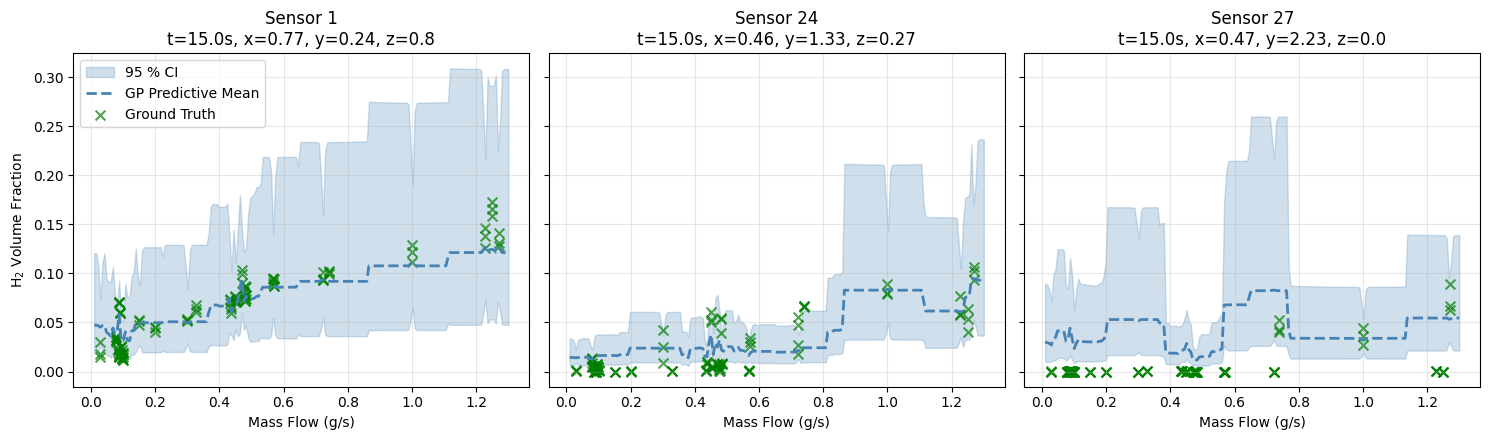

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import gpytorch

# --- Three fixed positions ---------------------------------------------------
positions = [
    {'time': 15.0, 'x': 0.77, 'y': 0.24, 'z': 0.80, 'label': 'Sensor 1'},
    {'time': 15.0, 'x': 0.46, 'y': 1.33, 'z': 0.27, 'label': 'Sensor 24'},
    {'time': 15.0, 'x': 0.47, 'y': 2.23, 'z': 0.00, 'label': 'Sensor 27'},
]

mass_flow_grid = np.linspace(0.01, 1.30, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
axes = axes.flatten()

for ax, pos in zip(axes, positions):
    # Build input grid
    grid = np.column_stack([
        np.full_like(mass_flow_grid, pos['time']),
        mass_flow_grid,
        np.full_like(mass_flow_grid, pos['x']),
        np.full_like(mass_flow_grid, pos['y']),
        np.full_like(mass_flow_grid, pos['z']),
    ])

    if x_scaler is not None:
        grid_scaled = x_scaler.transform(grid)
    else:
        grid_scaled = grid

    X_grid = torch.tensor(grid_scaled, dtype=torch.float64, device=device)

    # Predict
    model_vnngp.eval()
    likelihood_vnngp.eval()
    with torch.no_grad():
        pred = likelihood_vnngp(model_vnngp(X_grid))
        pred_mean = pred.mean.cpu().numpy()
        lower, upper = pred.confidence_region()
        lower = lower.cpu().numpy()
        upper = upper.cpu().numpy()

    is_beta = isinstance(likelihood_vnngp, gpytorch.likelihoods.BetaLikelihood)
    if not is_beta:
        if y_scaler is not None:
            pred_mean = np.exp(y_scaler.inverse_transform(pred_mean.reshape(-1, 1))).ravel()
            lower = np.exp(y_scaler.inverse_transform(lower.reshape(-1, 1))).ravel()
            upper = np.exp(y_scaler.inverse_transform(upper.reshape(-1, 1))).ravel()
        else:
            pred_mean = np.exp(pred_mean)
            lower = np.exp(lower)
            upper = np.exp(upper)

    # Ground truth
    tol = 0.01
    df_gt = df[
        (np.abs(df['time'] - pos['time']) < 1.0) &
        (np.abs(df['x'] - pos['x']) < tol) &
        (np.abs(df['y'] - pos['y']) < tol) &
        (np.abs(df['z'] - pos['z']) < tol)
    ].copy()

    # Plot
    ax.fill_between(mass_flow_grid, lower, upper, color='steelblue', alpha=0.25,
                    label='95 % CI' if ax == axes[0] else '')
    ax.plot(mass_flow_grid, pred_mean, color='steelblue', linewidth=2,
            linestyle='--', label='GP Predictive Mean' if ax == axes[0] else '')
    ax.scatter(df_gt['mass_flow'], df_gt['h2_volume_fraction'],
               c='green', marker='x', s=50, alpha=0.7,
               label='Ground Truth' if ax == axes[0] else '')

    ax.set_xlabel('Mass Flow (g/s)')
    ax.set_title(f"{pos['label']}\nt={pos['time']}s, x={pos['x']}, y={pos['y']}, z={pos['z']}")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('H$_2$ Volume Fraction')
axes[0].legend(loc='best')
plt.tight_layout()
plt.show()

# SVGP 4000 Beta

In [3]:
checkpoint = torch.load('models/approximate_indvAdditive_svgp_rbf_4000_beta_two_modes_300_lr8e-3.pth_best', map_location='cpu')
inducing_points = checkpoint['model_state_dict']['variational_strategy.inducing_points']
likelihood = gpytorch.likelihoods.BetaLikelihood().double().to('cpu')
model = SparseH2DispersionGP(inducing_points=inducing_points).double().to('cpu')

In [4]:
model_state_dict = checkpoint['model_state_dict']
likelihood_state_dict = checkpoint['likelihood_state_dict']

model.load_state_dict(model_state_dict)
likelihood.load_state_dict(likelihood_state_dict)

<All keys matched successfully>

In [5]:
import torch.nn.functional as F

state = checkpoint['model_state_dict']

for key in sorted(state.keys()):
    if 'covar_module' in key:
        val = state[key]
        if 'raw_outputscale' in key:
            print(f"{key:<50} → {F.softplus(val).item():.4f}")
        elif 'raw_lengthscale' in key:
            print(f"{key:<50} → {F.softplus(val).tolist()}")

covar_module.kernels.0.base_kernel.raw_lengthscale → [[2.72344758666502, 9.268701286513446]]
covar_module.kernels.0.base_kernel.raw_lengthscale_constraint.lower_bound → 0.6931471805599453
covar_module.kernels.0.base_kernel.raw_lengthscale_constraint.upper_bound → inf
covar_module.kernels.0.raw_outputscale             → 0.2889
covar_module.kernels.0.raw_outputscale_constraint.lower_bound → 0.6931
covar_module.kernels.0.raw_outputscale_constraint.upper_bound → inf
covar_module.kernels.1.base_kernel.raw_lengthscale → [[0.010461629830452197, 34.52231200725022]]
covar_module.kernels.1.base_kernel.raw_lengthscale_constraint.lower_bound → 0.6931471805599453
covar_module.kernels.1.base_kernel.raw_lengthscale_constraint.upper_bound → inf
covar_module.kernels.1.raw_outputscale             → 0.0012
covar_module.kernels.1.raw_outputscale_constraint.lower_bound → 0.6931
covar_module.kernels.1.raw_outputscale_constraint.upper_bound → inf
covar_module.kernels.10.base_kernel.raw_lengthscale → [[4.1975

In [6]:
# 1. Load model + checkpoint
device = 'cpu'
model_beta, likelihood_beta, checkpoint_beta = load_model('models/approximate_indvAdditive_svgp_rbf_4000_beta_two_modes_300_lr8e-3.pth_best', device=device)

# 2. Load test data (must be the same unified CSV used for training)
df = pd.read_csv('data/unified_raw_two_modes.csv')
df_test = df[df['split'] == 'test']

# 3. Evaluate
metrics = evaluate_gp_model(
    model=model_beta,
    likelihood=likelihood_beta,
    df_test=df_test,
    device=device,
    x_scaler=checkpoint_beta.get('x_scaler'),
    y_scaler=checkpoint_beta.get('y_scaler')
)


TEST EVALUATION
Test data: 28,188 points

Test Metrics:
  NLL:      -1.2255
  MAE:      0.020876
  RMSE:     0.026749


In [7]:
x_scaler = checkpoint_beta.get('x_scaler')   # StandardScaler or None
y_scaler = checkpoint_beta.get('y_scaler')   # StandardScaler or None

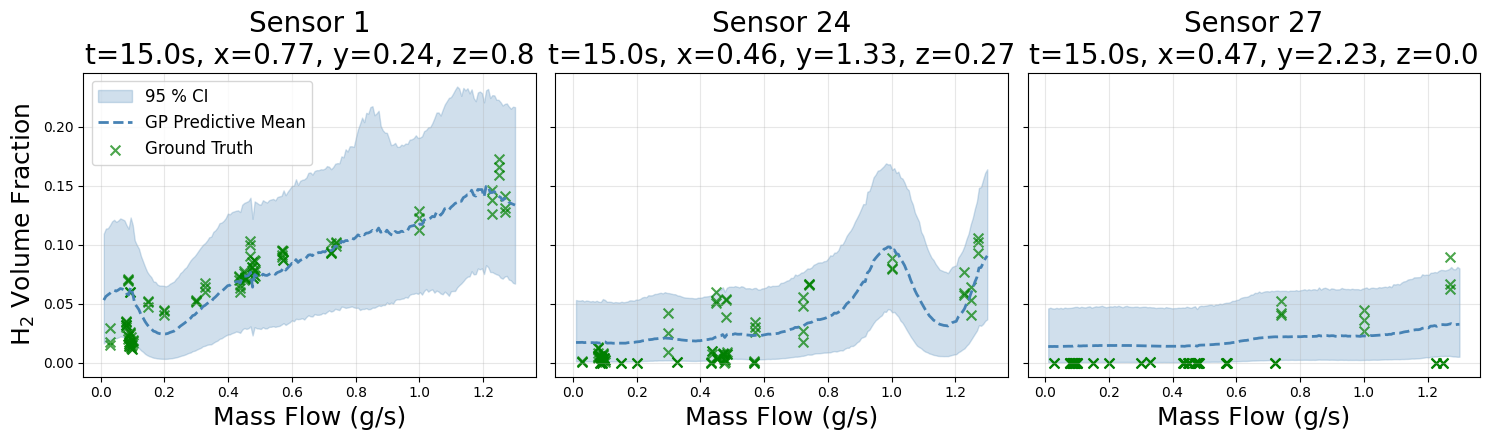

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import gpytorch

# --- Three fixed positions ---------------------------------------------------
positions = [
    {'time': 15.0, 'x': 0.77, 'y': 0.24, 'z': 0.80, 'label': 'Sensor 1'},
    {'time': 15.0, 'x': 0.46, 'y': 1.33, 'z': 0.27, 'label': 'Sensor 24'},
    {'time': 15.0, 'x': 0.47, 'y': 2.23, 'z': 0.00, 'label': 'Sensor 27'},
]

mass_flow_grid = np.linspace(0.01, 1.30, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
axes = axes.flatten()

for ax, pos in zip(axes, positions):
    # Build input grid
    grid = np.column_stack([
        np.full_like(mass_flow_grid, pos['time']),
        mass_flow_grid,
        np.full_like(mass_flow_grid, pos['x']),
        np.full_like(mass_flow_grid, pos['y']),
        np.full_like(mass_flow_grid, pos['z']),
    ])

    if x_scaler is not None:
        grid_scaled = x_scaler.transform(grid)
    else:
        grid_scaled = grid

    X_grid = torch.tensor(grid_scaled, dtype=torch.float64, device=device)

    # Predict
    model_beta.eval()
    likelihood_beta.eval()
    with torch.no_grad():
        pred = likelihood_beta(model_beta(X_grid))
        pred_mean = pred.mean
        if pred_mean.dim() == 2:
            pred_mean = pred_mean.mean(dim=0)
        if hasattr(pred, 'confidence_region'):
            lower, upper = pred.confidence_region()
            lower = lower.cpu().numpy()
            upper = upper.cpu().numpy()
        else:
            # Beta (and other torch distributions): use 2.5% and 97.5% quantiles
            # MC sample from the Beta predictive distribution
            n_samples = 5000
            samples = pred.sample(torch.Size([n_samples]))
            if samples.dim() == 3:
                samples = samples.reshape(-1, samples.shape[-1])
            lower = torch.quantile(samples, 0.025, dim=0).cpu().numpy().ravel()
            upper = torch.quantile(samples, 0.975, dim=0).cpu().numpy().ravel()

    is_beta = isinstance(likelihood_beta, gpytorch.likelihoods.BetaLikelihood)
    if not is_beta:
        if y_scaler is not None:
            pred_mean = np.exp(y_scaler.inverse_transform(pred_mean.reshape(-1, 1))).ravel()
            lower = np.exp(y_scaler.inverse_transform(lower.reshape(-1, 1))).ravel()
            upper = np.exp(y_scaler.inverse_transform(upper.reshape(-1, 1))).ravel()
        else:
            pred_mean = np.exp(pred_mean)
            lower = np.exp(lower)
            upper = np.exp(upper)

    # Ground truth
    tol = 0.01
    df_gt = df[
        (np.abs(df['time'] - pos['time']) < 1.0) &
        (np.abs(df['x'] - pos['x']) < tol) &
        (np.abs(df['y'] - pos['y']) < tol) &
        (np.abs(df['z'] - pos['z']) < tol)
    ].copy()

    # Plot
    ax.fill_between(mass_flow_grid.ravel(), lower, upper, color='steelblue', alpha=0.25,
                    label='95 % CI' if ax == axes[0] else '')
    ax.plot(mass_flow_grid, pred_mean, color='steelblue', linewidth=2,
            linestyle='--', label='GP Predictive Mean' if ax == axes[0] else '')
    ax.scatter(df_gt['mass_flow'], df_gt['h2_volume_fraction'],
               c='green', marker='x', s=50, alpha=0.7,
               label='Ground Truth' if ax == axes[0] else '')

    ax.set_xlabel('Mass Flow (g/s)', fontsize=18)
    ax.set_title(f"{pos['label']}\nt={pos['time']}s, x={pos['x']}, y={pos['y']}, z={pos['z']}", fontsize=20)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('H$_2$ Volume Fraction', fontsize=18)
axes[0].legend(loc='best', fontsize=12)
plt.tight_layout()
plt.show()

t=0s: max at (x=0.00, y=0.00, z=0.46), value=0.0741
t=15s: max at (x=0.00, y=0.00, z=0.51), value=0.1961
t=30s: max at (x=0.00, y=0.16, z=0.46), value=0.2882
t=45s: max at (x=0.00, y=0.16, z=0.46), value=0.2721
t=60s: max at (x=0.00, y=0.16, z=0.51), value=0.2352
t=75s: max at (x=0.00, y=0.00, z=0.51), value=0.2802


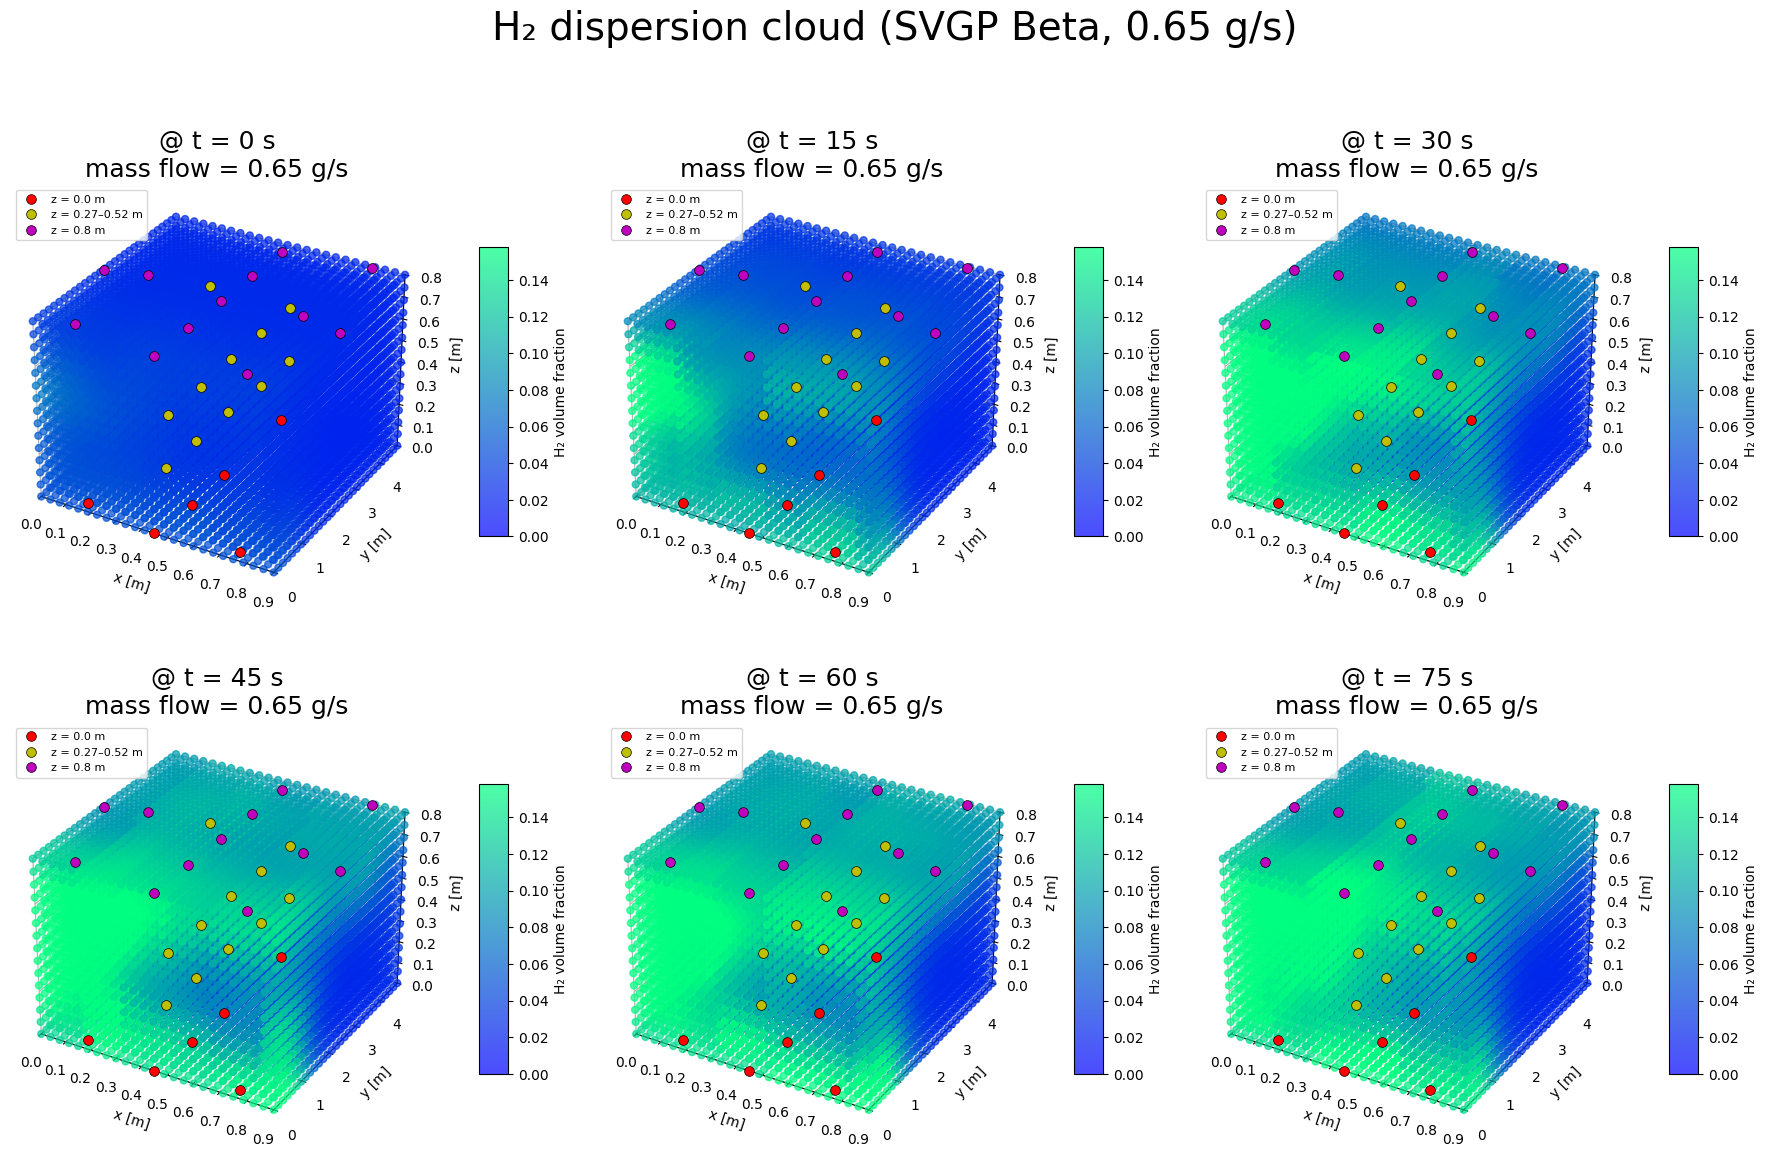

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from build_dataset import SENSOR_POSITIONS
from h2_dispersion_gp import load_model

# --- Settings ---
device = 'cuda:0'
model_path = 'models/approximate_indvAdditive_svgp_rbf_4000x_beta_two_modes_300_lr9e-3.pth_best'
mass_flow = 0.65  # g/s
time_steps = [0, 15, 30, 45, 60, 75]
threshold = 0.01
batch_size = 2000

# --- Load model ---
model, likelihood, checkpoint = load_model(model_path, device=device)
x_scaler = checkpoint['x_scaler']
model.eval()
likelihood.eval()

# --- Build 3D grid ---
x = np.linspace(0.0, 0.9, 25)
y = np.linspace(0.0, 4.7, 30)
z = np.linspace(0.0, 0.8, 15)
X_grid, Y_grid, Z_grid = np.meshgrid(x, y, z, indexing='ij')
grid_points = np.stack([X_grid.ravel(), Y_grid.ravel(), Z_grid.ravel()], axis=1)
n_points = len(grid_points)

# --- Prediction helper ---
def predict_at_time(t):
    inputs = np.column_stack([
        np.full(n_points, t),
        np.full(n_points, mass_flow),
        grid_points[:, 0],
        grid_points[:, 1],
        grid_points[:, 2],
    ])
    inputs_scaled = x_scaler.transform(inputs)
    inputs_t = torch.tensor(inputs_scaled, dtype=torch.float64, device=device)
    
    means = []
    with torch.no_grad():
        for i in range(0, n_points, batch_size):
            batch = inputs_t[i:i+batch_size]
            pred = likelihood(model(batch))
            mean = pred.mean.cpu().numpy()
            # Beta likelihood can return (num_mc_samples, batch_size)
            if mean.ndim > 1:
                mean = mean.mean(axis=0)
            means.append(mean.ravel())
    
    return np.concatenate(means)

# Split sensors by z-height
low_sensors = [p for p in SENSOR_POSITIONS.values() if p[2] < 0.2]
mid_sensors = [p for p in SENSOR_POSITIONS.values() if 0.2 <= p[2] <= 0.6]
high_sensors = [p for p in SENSOR_POSITIONS.values() if p[2] > 0.6]

low_arr = np.array(low_sensors)
mid_arr = np.array(mid_sensors)
high_arr = np.array(high_sensors)

concentrations = {t: predict_at_time(t) for t in time_steps}
all_conc = np.concatenate(list(concentrations.values()))
vmax = np.percentile(all_conc[all_conc > 1e-4], 95)

for t, conc in concentrations.items():
    idx = np.argmax(conc)
    print(f"t={t}s: max at (x={grid_points[idx,0]:.2f}, y={grid_points[idx,1]:.2f}, z={grid_points[idx,2]:.2f}), value={conc[idx]:.4f}")

n_cols = 3
n_rows = int(np.ceil(len(time_steps) / n_cols))
fig = plt.figure(figsize=(18, 12))

for idx, t in enumerate(time_steps):
    conc = concentrations[t]
    mask = conc > 1e-4
    
    ax = fig.add_subplot(n_rows, n_cols, idx + 1, projection='3d')
    
    # Predicted H2 cloud
    sc = ax.scatter(
        grid_points[mask, 0],
        grid_points[mask, 1],
        grid_points[mask, 2],
        c=conc[mask],
        cmap='winter',
        vmin=0.0,
        vmax=vmax,
        s=25,
        alpha=0.7,
        zorder=1,
    )

    # Sensors on top
    # Sensors by height
    if len(low_arr) > 0:
        ax.plot(low_arr[:, 0], low_arr[:, 1], low_arr[:, 2], 'ro',
                markersize=7, markeredgecolor='black', markeredgewidth=0.5,
                label='z = 0.0 m', zorder=10)
    if len(mid_arr) > 0:
        ax.plot(mid_arr[:, 0], mid_arr[:, 1], mid_arr[:, 2], 'yo',
                markersize=7, markeredgecolor='black', markeredgewidth=0.5,
                label='z = 0.27–0.52 m', zorder=10)
    if len(high_arr) > 0:
        ax.plot(high_arr[:, 0], high_arr[:, 1], high_arr[:, 2], 'mo',
                markersize=7, markeredgecolor='black', markeredgewidth=0.5,
                label='z = 0.8 m', zorder=10)

    
    ax.set_title(f'@ t = {t} s\nmass flow = {mass_flow} g/s', fontsize=18)
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.set_zlabel('z [m]')
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(y.min(), y.max())
    ax.set_zlim(z.min(), z.max())
    ax.legend(loc='upper left', fontsize=8)
    
    fig.colorbar(sc, ax=ax, shrink=0.5, aspect=10, label='H₂ volume fraction', pad=0.1)


fig.suptitle(f'H₂ dispersion cloud (SVGP Beta, {mass_flow} g/s)', fontsize=28, y=1.02)
plt.tight_layout()
plt.show()

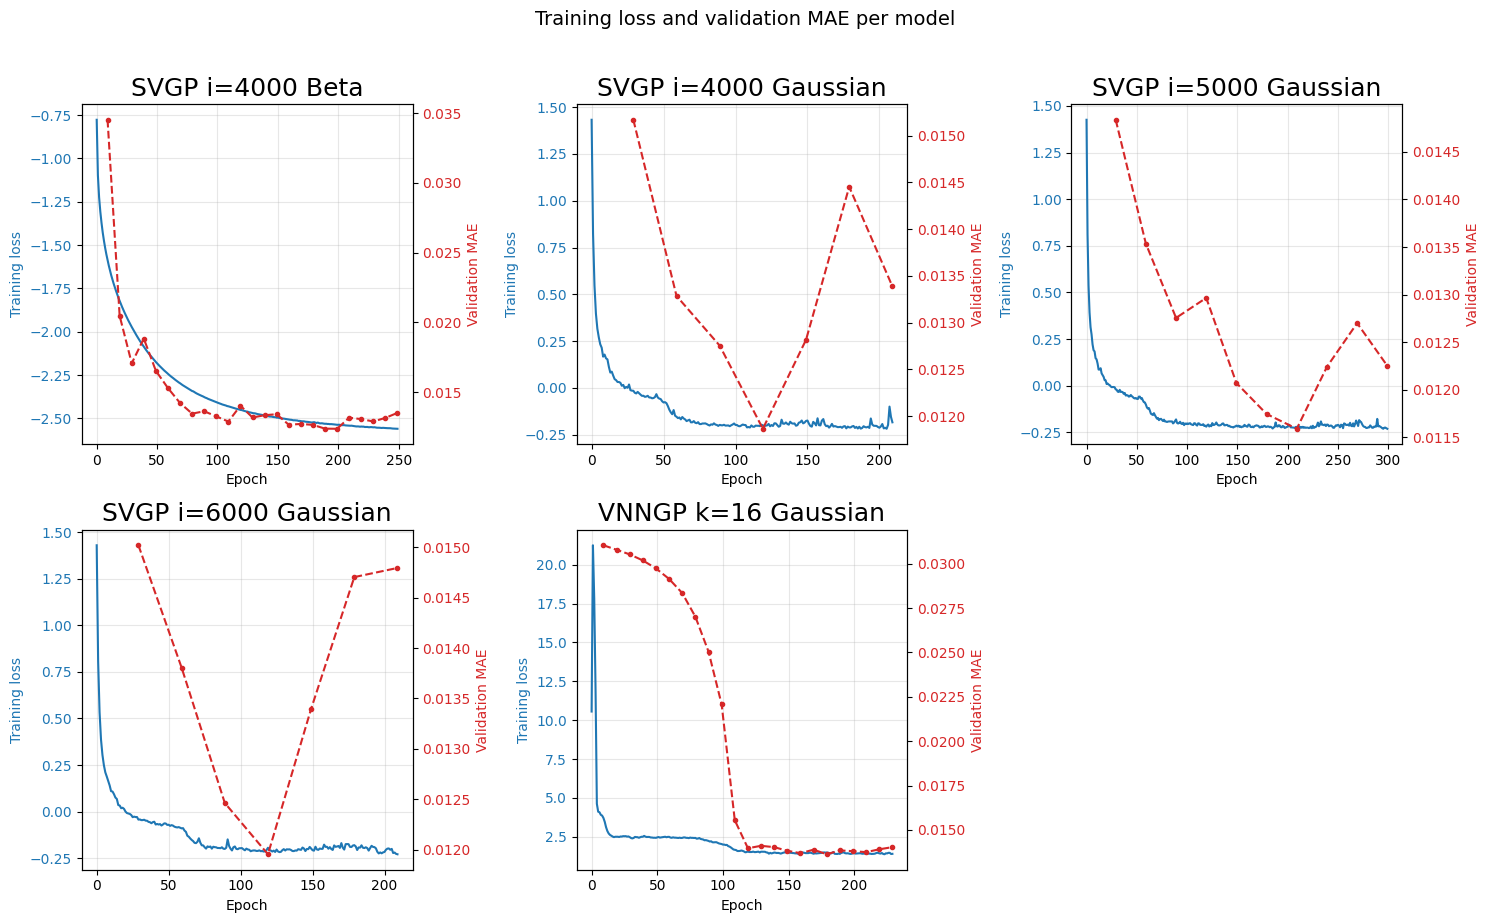

In [10]:
import json
import re
from pathlib import Path
import matplotlib.pyplot as plt

history_files = [
    "models/approximate_indvAdditive_svgp_rbf_4000_beta_two_modes_300_lr8e-3_history.json",
    "models/approximate_indvAdditive_svgp_rbf_4000_gaussian_two_modes_300_lr8e-3_history.json",
    "models/approximate_indvAdditive_svgp_rbf_5000_gaussian_two_modes_300_lr8e-3_history.json",
    "models/approximate_indvAdditive_svgp_rbf_6000_gaussian_two_modes_300_lr8e-3_history.json",
    "models/approximate_indvAdditive_vnngp_rbf_k16_gaussian_two_modes_300_lr9e-3_history.json",
]

# Manually define subplot titles here
plot_labels = {
    "models/approximate_indvAdditive_svgp_rbf_4000_beta_two_modes_300_lr8e-3_history.json": "SVGP i=4000 Beta",
    "models/approximate_indvAdditive_svgp_rbf_4000_gaussian_two_modes_300_lr8e-3_history.json": "SVGP i=4000 Gaussian",
    "models/approximate_indvAdditive_svgp_rbf_5000_gaussian_two_modes_300_lr8e-3_history.json": "SVGP i=5000 Gaussian",
    "models/approximate_indvAdditive_svgp_rbf_6000_gaussian_two_modes_300_lr8e-3_history.json": "SVGP i=6000 Gaussian",
    "models/approximate_indvAdditive_vnngp_rbf_k16_gaussian_two_modes_300_lr9e-3_history.json": "VNNGP k=16 Gaussian",
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, path in zip(axes, history_files):
    with open(path) as f:
        hist = json.load(f)

    label = plot_labels[path]

    # Training loss on left axis (linear scale)
    color_loss = "tab:blue"
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training loss", color=color_loss)
    ax.plot(hist["epochs"], hist["train_epoch_loss"], color=color_loss, linewidth=1.5, label="train loss")
    ax.tick_params(axis="y", labelcolor=color_loss)

    # Validation MAE on right axis
    ax2 = ax.twinx()
    color_mae = "tab:red"
    ax2.set_ylabel("Validation MAE", color=color_mae)
    ax2.plot(hist["val_epochs"], hist["val_MAE"], color=color_mae, linestyle="--", marker="o", markersize=3, label="val MAE")
    ax2.tick_params(axis="y", labelcolor=color_mae)

    ax.set_title(label, fontsize=18)
    ax.grid(True, alpha=0.3)

fig.delaxes(axes[-1])
fig.suptitle("Training loss and validation MAE per model", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()